# PIPELINE STAGE — canonical RF design scoring

This top section is what `run_all.sh` runs headlessly (via `nbconvert`). It is self-contained:
it reads paths from `config`, trains the Random Forest on **all** labelled data (`eval.csv`) for the
selected `DATASET`, scores the unlabelled designs (`design.csv`), and writes the canonical outputs
under `data/processed/evaluation/<dataset>/ranking/`:

- `rf_design_scores.csv` — `sample, p_binder[, dataset]` (the score `run_consensus.py` consumes)
- `rf_cv_metrics.csv` — grouped-CV ROC-AUC / PR-AUC (how well the RF separates binders)
- `rf_importances.csv` — impurity feature importances

The exploratory cells below are kept for reference and are **not** part of the pipeline stage.

In [ ]:
# === PIPELINE STAGE: canonical RF design scoring (self-contained) ===
# Trains RF on ALL labelled eval data for the selected DATASET and scores design.csv.
# Writes ranking/rf_design_scores.csv (sample, p_binder[, dataset]) + rf_cv_metrics.csv + rf_importances.csv.
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.metrics import matthews_corrcoef

from config.datasets import cfg
from config.paths import RAW_DATA_DIR, EVALUATION_DIR
from analysis.distributions import get_numeric_metrics   # leakage-safe feature selector

_base = RAW_DATA_DIR / cfg.name
_out = EVALUATION_DIR / cfg.name / 'ranking'
_out.mkdir(parents=True, exist_ok=True)

_eval = pd.read_csv(_base / 'eval.csv')
_design = pd.read_csv(_base / 'design.csv') if (_base / 'design.csv').exists() else None

# Features = numeric metric columns only. get_numeric_metrics drops meta + experimental
# readouts (sample/binder/binder_type/dataset/iteration/KD[M]/EC50[M]) centrally via config,
# so no metadata or label-adjacent column can leak in as a feature.
_features = get_numeric_metrics(_eval)
_Xtr = _eval[_features]
_ytr = _eval['binder'].astype(int)
assert not ({'binder','KD[M]','EC50[M]','iteration','binder_type','dataset'} & set(_features)), \
    'leak: a meta/experimental column entered the feature set'
print(f"[{cfg.name}] train: {len(_Xtr)} labelled rows, {_Xtr.shape[1]} features, "
      f"classes={_ytr.value_counts().to_dict()}")

# RF hyperparameters: identical to the exploratory model in the cells below.
_rf = RandomForestClassifier(n_estimators=300, max_depth=3, min_samples_split=8,
    min_samples_leaf=4, max_features='sqrt', class_weight='balanced_subsample',
    bootstrap=True, oob_score=True, random_state=42, n_jobs=-1)

# --- CV evaluation: grouped by parent lineage (first token of sample) so mutants of
#     the same parent never split across folds (avoids optimistic leakage in the estimate).
_groups = _eval['sample'].astype(str).str.split('_').str[0]
_n_splits = int(min(5, _ytr.value_counts().min(), _groups.nunique()))
_cv_rows = []
if _n_splits >= 2:
    _cv = StratifiedGroupKFold(n_splits=_n_splits, shuffle=True, random_state=42)
    _res = cross_validate(_rf, _Xtr, _ytr, groups=_groups, cv=_cv,
                          scoring=['average_precision'])
    _cv_rows = [
        {'metric': 'pr_auc', 'mean': round(float(_res['test_average_precision'].mean()), 4),
         'std': round(float(_res['test_average_precision'].std()), 4), 'n_splits': _n_splits},
    ]
    # supplementary: MCC at the 0.5 operating threshold on out-of-fold predictions
    _oof = cross_val_predict(_rf, _Xtr, _ytr, groups=_groups, cv=_cv, method='predict_proba')[:, 1]
    _mcc = matthews_corrcoef(_ytr, (_oof >= 0.5).astype(int)) if _ytr.nunique() > 1 else float('nan')
    _cv_rows.append({'metric': 'mcc@0.5', 'mean': round(float(_mcc), 4), 'std': float('nan'), 'n_splits': _n_splits})
    print('  CV:', _cv_rows)
else:
    print('  CV skipped: too few samples/groups per class for grouped folds')
pd.DataFrame(_cv_rows).to_csv(_out / 'rf_cv_metrics.csv', index=False)

# --- final model: fit on ALL labelled data, then score the designs ---
_rf.fit(_Xtr, _ytr)
print('  OOB score:', round(float(_rf.oob_score_), 4))
pd.DataFrame({'metric': _Xtr.columns, 'importance': _rf.feature_importances_}) \
    .sort_values('importance', ascending=False).to_csv(_out / 'rf_importances.csv', index=False)

if _design is not None and len(_design):
    _Xde = _design.reindex(columns=_features)   # same feature order; missing cols -> NaN (RF tolerates)
    _scores = _design[[c for c in ('sample', 'dataset') if c in _design.columns]].copy()
    _scores['p_binder'] = _rf.predict_proba(_Xde)[:, 1]
    _scores = _scores.sort_values('p_binder', ascending=False)
    _scores.to_csv(_out / 'rf_design_scores.csv', index=False)
    print(f"  wrote rf_design_scores.csv ({len(_scores)} designs) + rf_cv_metrics.csv + rf_importances.csv -> {_out}")
else:
    print(f"  no design.csv for '{cfg.name}'; wrote rf_cv_metrics.csv + rf_importances.csv only")

# optional provenance record when run via run_all.sh (RUN_DIR set)
try:
    _rd = os.environ.get('RUN_DIR')
    if _rd:
        from config.provenance import record_stage
        record_stage(_rd, 'ranking_rf', outputs=['ranking/rf_design_scores.csv',
                                                 'ranking/rf_cv_metrics.csv', 'ranking/rf_importances.csv'])
except Exception as _e:
    print('  provenance note skipped:', _e)


In [ ]:
import pandas as pd
import numpy as np
from analysis.distributions import get_numeric_metrics   # central feature selector (drops config.EXCLUDE_COLUMNS)

from config.paths import EXTERNAL_DATA_ROOT   # portable data roots (default = scicore)
_SCHWEDE = EXTERNAL_DATA_ROOT.parent            # /scicore/home/schwede
base = f"{EXTERNAL_DATA_ROOT}/tests/test/data/raw"

# train (trees are scale/direction invariant, so raw metrics are fine)
eval_df = pd.read_csv(f"{base}/current/eval.csv")
y_train = eval_df["binder"].astype(int)
# Features = numeric metric columns only. get_numeric_metrics drops meta + experimental readouts
# (sample/source/type/binder/binder_type/dataset/iteration/KD[M]/EC50[M]) centrally via config,
# so no metadata or label-adjacent column can leak in as a feature.
feature_cols = get_numeric_metrics(eval_df)
X_train = eval_df[feature_cols]
assert not ({"binder","KD[M]","EC50[M]","iteration","binder_type","dataset"} & set(feature_cols)), \
    "leak: a meta/experimental column is in the feature set"
print(f"train: {len(X_train)} rows, {X_train.shape[1]} features, classes={y_train.value_counts().to_dict()}")
X_train.head()

In [ ]:
# test
design_df = pd.read_csv(f"{base}/snir/eval.csv")
X_test = design_df.reindex(columns=feature_cols)     # feature order
y_test = design_df["binder"]

print(f"test: {len(X_test)} rows, {X_test.shape[1]} features, classes={y_test.value_counts().to_dict()}")
X_test.head()

test: 35 rows, 49 features, classes={0: 32, 1: 3}


,af3_pae,af3_plddt,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq2,af3_lis,af3_iptm,af3_ptm,cf_af3_rmsd,...,boltz_template_ptm,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis
0,2.593883,95.404666,1.993750,95.036725,0.788184,0.88085,0.75930,0.920,0.4800,0.1600,...,0.990514,0.986901,0.985055,0.985220,0.256930,0.278017,0.960036,0.937455,0.96685,0.87115
1,2.572969,95.599717,2.020938,94.909961,0.785245,0.89390,0.75510,0.915,0.4800,0.1665,...,0.989588,0.985429,0.987334,0.987299,0.258769,0.284754,0.952718,0.925141,0.96935,0.85870
2,3.486349,92.439163,5.111071,69.144182,0.088382,0.18020,0.34295,0.570,0.4700,0.1825,...,0.990548,0.986835,0.982311,0.979760,0.255680,0.283189,0.943557,0.906099,0.92390,0.82455
3,2.815847,95.282854,2.100000,94.730775,0.765295,0.88195,0.73785,0.910,0.4775,0.1800,...,0.991181,0.987563,0.979963,0.975488,0.256625,0.289870,0.943841,0.908519,0.92900,0.85605
4,2.790728,94.871984,2.275417,92.998114,0.769552,0.85065,0.74445,0.915,0.4775,0.1590,...,0.991275,0.987761,0.983894,0.983133,0.254981,0.275365,0.961354,0.939275,0.96220,0.87810


In [ ]:
# val
val_df = pd.read_csv(f"{base}/originals/eval.csv")
X_val = val_df.reindex(columns=feature_cols)     # feature order
y_val = val_df["binder"]

print(f"test: {len(X_val)} rows, {X_val.shape[1]} features, classes={y_val.value_counts().to_dict()}")
X_val.head()

test: 24 rows, 49 features, classes={1: 18, 0: 6}


,af3_pae,af3_plddt,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq2,af3_lis,af3_iptm,af3_ptm,cf_af3_rmsd,...,boltz_template_ptm,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis
0,2.244009,96.092315,1.877908,95.060174,0.774714,0.881900,0.733733,0.903333,0.636667,0.195667,...,0.986434,0.980540,0.974422,0.968442,0.270937,0.426294,0.880714,0.735099,0.599200,0.764267
1,2.152426,96.312822,1.935269,95.582281,0.782585,0.907800,0.742533,0.916667,0.636667,0.171000,...,0.985076,0.978858,0.975763,0.971518,0.277812,0.500535,0.852264,0.661585,0.885900,0.730767
2,3.011986,94.148048,2.434329,87.922670,0.385261,0.581767,0.532300,0.743333,0.620000,0.277000,...,0.979408,0.969304,0.973184,0.961770,0.296332,0.714163,0.779386,0.523009,0.540567,0.639033
3,3.044313,94.055147,2.818122,87.741249,0.364383,0.536667,0.522133,0.723333,0.620000,0.377667,...,0.985718,0.980804,0.973990,0.968657,0.275562,0.475635,0.874281,0.695617,0.867367,0.769200
4,2.198550,96.363526,1.911455,95.590822,0.816753,0.899800,0.751567,0.916667,0.636667,0.194000,...,0.988214,0.983516,0.976713,0.977079,0.261944,0.325992,0.916153,0.844432,0.938300,0.818133


In [4]:
X_val.isna().sum()

af3_pae                                0
af3_plddt                              0
af3_ipae                               0
af3_iplddt                             0
af3_ipsae                              0
af3_pdockq2                            0
af3_lis                                0
af3_iptm                               0
af3_ptm                                0
cf_af3_rmsd                            0
cf_pae                                 0
cf_plddt                               0
cf_ipae                                0
cf_iplddt                              0
cf_ipsae                               0
cf_pdockq2                             0
cf_lis                                 0
cf_iptm                                0
cf_ptm                                 0
pred_ilddt                             0
pred_lddt                              0
esmfold2_ipae                         11
esmfold2_iplddt                       11
esmfold2_plddt                        11
esmfold2_pae    

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300,max_depth=3,min_samples_split=8,min_samples_leaf=4,max_features="sqrt",class_weight="balanced_subsample",bootstrap=True,oob_score=True,random_state=42,n_jobs=-1,) 
# rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=2, max_depth=5, class_weight="balanced", oob_score=True, random_state=42, n_jobs=-1) 
# max_depth = The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
# min_samples_split = The minimum number of samples required to split an internal node
# min_samples_leaf = The minimum number of samples required to be at a leaf node
# max_features = The number of features to consider when looking for the best split. If “sqrt”, then max_features=sqrt(n_features). Default: sqrt
# class_weight: The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y)). he “balanced_subsample” mode is the same as “balanced” except that weights are computed based on the bootstrap sample for every tree grown.
# oob_score = use out-of-bag samples to estimate the generalization score.
# bootstrap = Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree. T
# random_state =Popular integer random seeds are 0 and 42. 
# n_jobs = The number of jobs to run in parallel. -1 means using all processors.

In [6]:
# cross validation v1 (deafault "For int/None inputs, if the estimator is a classifier and y is either binary or multiclass, StratifiedKFold is used.")
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

cv_res = cross_validate(rf, X_train, y_train, cv=cv, scoring=["roc_auc", "average_precision"])
print(cv_res["test_roc_auc"].mean(), "±", cv_res["test_roc_auc"].std())
print(cv_res["test_average_precision"].mean(), "±", cv_res["test_average_precision"].std())

oof_probs = cross_val_predict(rf, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
print(confusion_matrix(y_train, (oof_probs >= 0.5).astype(int)))

0.8431481481481482 ± 0.06836218401293095
0.9129450410700413 ± 0.03569629921543673
[[18  9]
 [ 8 36]]


In [ ]:
# cross validation v2 --> grouped by the first part of the sample name (parent lineage),
# so mutants of the same parent do not split across folds
from sklearn.model_selection import StratifiedGroupKFold

groups = eval_df["sample"].str.split("_").str[0]       # parent / lineage id
n_splits = min(5, y_train.value_counts().min(), groups.nunique())   # cannot exceed minority class / #groups

cv_group = StratifiedGroupKFold(n_splits=n_splits, random_state=42, shuffle=True)

cv_group_res = cross_validate(rf, X_train, y_train,  groups=groups, cv=cv_group, scoring=["roc_auc", "average_precision"])
print(cv_group_res["test_roc_auc"].mean(), "±", cv_group_res["test_roc_auc"].std())
print(cv_group_res["test_average_precision"].mean(), "±", cv_group_res["test_average_precision"].std())

oof_probs = cross_val_predict(rf, X_train, y_train, groups=groups, cv=cv_group, method="predict_proba")[:, 1]
print(confusion_matrix(y_train, (oof_probs >= 0.5).astype(int)))

In [8]:
rf.fit(X_train, y_train)
print("OOB score:", rf.oob_score_)

OOB score: 0.704225352112676


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# In-sample TRAINING diagnostics (intended): how well the model fits the training set.
# For generalization use the CV OOF metrics (cells above) or the held-out val set.
y_train_probs = rf.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_probs >= 0.5).astype(int)

precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)
accuracy = accuracy_score(y_train, y_train_pred)

print(f"Precision (train): {precision:.3f}")
print(f"Recall (train): {recall:.3f}")
print(f"F1 Score (train): {f1:.3f}")
print(f"Accuracy (train): {accuracy:.3f}")

# Precision at top 10% (train)
import numpy as np
top_10pct_count = max(1, int(len(y_train_probs) * 0.1))
top_10pct_idx = np.argsort(y_train_probs)[::-1][:top_10pct_count]
precision_at_10pct = (y_train.iloc[top_10pct_idx] == 1).sum() / top_10pct_count
print(f"Precision at 10% (train): {precision_at_10pct:.3f} ({(y_train.iloc[top_10pct_idx] == 1).sum()}/{top_10pct_count})")

In [10]:
design_df["p_binder"] = rf.predict_proba(X_test)[:, 1]   # probs
ranked = design_df.sort_values("p_binder", ascending=False)[["sample", "binder","p_binder"]]   # sort descending rank
print(ranked) #.head(20)
# ranked.to_csv(f"{base}/design_rf_scores.csv", index=False)

                  sample  binder  p_binder
17  5ig7_abc_cut_B_G114A       0  0.961663
1           5ig7_abc_cut       1  0.959747
9   5ifj_abc_cut_B_L116A       0  0.943728
0           5ifj_abc_cut       1  0.943087
3   5ifj_abc_cut_A_D111A       0  0.941138
4   5ifj_abc_cut_A_K110A       0  0.940646
18  5ig7_abc_cut_B_L116A       0  0.940610
15   5ig7_abc_cut_A_Y66A       0  0.940525
14   5ig7_abc_cut_A_W52A       0  0.939079
13  5ig7_abc_cut_A_K110A       0  0.937092
19   5ig7_abc_cut_B_V38A       0  0.930679
10   5ifj_abc_cut_B_V38A       0  0.930423
5    5ifj_abc_cut_A_S64A       0  0.918129
11  5ifj_abc_cut_B_W107A       0  0.904833
30   5ijk_acx_cut_B_W56A       0  0.887664
7    5ifj_abc_cut_A_Y66A       0  0.873713
6    5ifj_abc_cut_A_W52A       0  0.873436
26  5ijk_acx_cut_A_T113A       0  0.846514
21   5ig7_abc_cut_B_Y37A       0  0.824813
34   5ijk_acx_cut_B_Y38A       0  0.802498
12   5ifj_abc_cut_B_Y37A       0  0.784159
33   5ijk_acx_cut_B_Y31A       0  0.766851
2          

    sample  binder  p_binder
22  2D4_23       1  0.897463
14  2D4_15       1  0.824467
19  2D4_20       1  0.816871
4    2D4_5       1  0.816684
20  2D4_21       0  0.810705
7    2D4_8       1  0.791447
11  2D4_12       1  0.782303
1    2D4_2       1  0.773239
0    2D4_1       1  0.764430
9   2D4_10       1  0.764366
21  2D4_22       1  0.758471
23  2D4_24       1  0.751660
8    2D4_9       1  0.750678
12  2D4_13       1  0.744993
15  2D4_16       1  0.704323
18  2D4_19       0  0.697630
17  2D4_18       1  0.687110
3    2D4_4       0  0.638129
5    2D4_6       0  0.627947
2    2D4_3       0  0.520163
10  2D4_11       1  0.491190
16  2D4_17       1  0.479152
6    2D4_7       0  0.455556
13  2D4_14       1  0.322725
Precision at 10% (precision@10): 1.000 (2/2)
Overall Precision at threshold 0.5: 0.750
Optimal threshold (max AUPRC segment): 0.817 with Precision=1.000, Recall=0.167


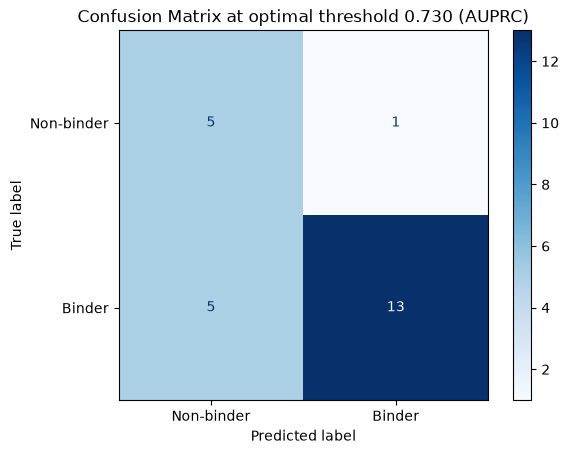

In [11]:
import numpy as np
from sklearn.metrics import precision_score, precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict probabilities
val_df["p_binder"] = rf.predict_proba(X_val)[:, 1]
ranked = val_df.sort_values("p_binder", ascending=False)[["sample", "binder", "p_binder"]]
print(ranked)  # .head(20)

# Precision at top 10% (precision@10%)
top_10pct_count = max(1, int(len(ranked) * 0.1))
top_10pct = ranked.head(top_10pct_count)
precision_at_10pct = (top_10pct["binder"] == 1).sum() / top_10pct_count
print(f"Precision at 10% (precision@10): {precision_at_10pct:.3f} ({(top_10pct['binder'] == 1).sum()}/{top_10pct_count})")

# Overall precision at default threshold 0.5
threshold_default = 0.5
pred_binary_default = (val_df["p_binder"] >= threshold_default).astype(int)
overall_precision_default = precision_score(val_df["binder"], pred_binary_default)
print(f"Overall Precision at threshold 0.5: {overall_precision_default:.3f}")

# Find optimal threshold by maximizing area under the precision-recall curve (AUPRC)
precision, recall, thresholds = precision_recall_curve(val_df["binder"], val_df["p_binder"])
# thresholds is length N-1, precision/recall are N, so thresholds[i] is for (precision[i+1], recall[i+1])

# Calculate area under PR curve for each threshold:
prc_areas = []
for i in range(len(thresholds)):
    # Area from threshold i to next, using trapezoidal rule for segment
    # Use points (recall[i], precision[i]), (recall[i+1], precision[i+1])
    prc_areas.append(auc([recall[i], recall[i+1]], [precision[i+1], precision[i]]))  # precision[i+1] aligns with thresholds[i]
prc_areas = np.array(prc_areas)

if len(prc_areas) > 0:
    optimal_idx = np.argmax(prc_areas)
    optimal_threshold = thresholds[optimal_idx]
    # Use the precision at threshold corresponding to (i+1)
    optimal_prec = precision[optimal_idx + 1]
    optimal_rec = recall[optimal_idx + 1]
    print(f"Optimal threshold (max AUPRC segment): {optimal_threshold:.3f} with Precision={optimal_prec:.3f}, Recall={optimal_rec:.3f}")
else:
    optimal_threshold = 0.5  # fallback
    print(f"No valid precision-recall segments: using default threshold {optimal_threshold}")

optimal_threshold = 0.73
# Confusion matrix at optimal threshold by AUPRC
pred_binary_optimal = (val_df["p_binder"] >= optimal_threshold).astype(int)
cm = confusion_matrix(val_df["binder"], pred_binary_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-binder", "Binder"])
fig, ax = plt.subplots()
disp.plot(ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix at optimal threshold {optimal_threshold:.3f} (AUPRC)")
plt.show()

In [ ]:
# rf built-in (impurity/Gini) feature importance -- IN-SAMPLE and biased toward high-cardinality /
# continuous features. Prefer the held-out permutation importance (next cell) for a trustworthy ranking.
rf_imp = (pd.DataFrame({"metric": X_train.columns,"importance": rf.feature_importances_}).sort_values("importance", ascending=False))

print(rf_imp)

In [ ]:
# permutation feature importance on HELD-OUT folds, using the GROUPED CV (no lineage leakage)
import numpy as np, pandas as pd
from sklearn.base import clone
from sklearn.inspection import permutation_importance

imps = []
for tr, te in cv_group.split(X_train, y_train, groups):            # grouped folds
    m = clone(rf).fit(X_train.iloc[tr], y_train.iloc[tr])          # fit on the training folds
    r = permutation_importance(m, X_train.iloc[te], y_train.iloc[te], scoring="average_precision", n_repeats=10, random_state=42, n_jobs=1)  # score on hold-out
    imps.append(r.importances_mean)

imp = (pd.DataFrame(imps, columns=X_train.columns).mean().sort_values(ascending=False).rename_axis("metric").rename("importance").reset_index())
print(imp)

In [14]:
cv_group

StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42,
    )),
    # ("clf", LogisticRegression(
    # solver="saga",
    # l1_ratio=0.5,   # elastic net
    # C=0.01,
    # class_weight="balanced",
    # max_iter=10000,
    # random_state=42,
    # )),
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
}

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv_group,
    scoring="average_precision",
    n_jobs=-1,
    refit=True,
)

search.fit(X_train, y_train, groups=groups)

clf = search.best_estimator_
print("Best C:", search.best_params_)
print("Best CV AP:", search.best_score_)

train_probs = clf.predict_proba(X_train)[:, 1]
test_probs = clf.predict_proba(X_test)[:, 1]

Best C: {'clf__C': 0.01}
Best CV AP: 0.8839222690425697


/scicore/home/schwede/follon0000/mambaforge/envs/esmfold2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/scicore/home/schwede/follon0000/mambaforge/envs/esmfold2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of pen

In [16]:
design_df["p_binder_clf"] = clf.predict_proba(X_test)[:, 1]   # probs
ranked = design_df.sort_values("p_binder_clf", ascending=False)[["sample", "binder","p_binder_clf"]]   # sort descending rank
print(ranked) #.head(20)
# ranked.to_csv(f"{base}/design_rf_scores.csv", index=False)

                  sample  binder  p_binder_clf
17  5ig7_abc_cut_B_G114A       0      0.712957
15   5ig7_abc_cut_A_Y66A       0      0.707327
1           5ig7_abc_cut       1      0.704358
0           5ifj_abc_cut       1      0.704226
4   5ifj_abc_cut_A_K110A       0      0.700653
5    5ifj_abc_cut_A_S64A       0      0.700217
13  5ig7_abc_cut_A_K110A       0      0.696884
18  5ig7_abc_cut_B_L116A       0      0.696869
30   5ijk_acx_cut_B_W56A       0      0.696293
19   5ig7_abc_cut_B_V38A       0      0.693916
26  5ijk_acx_cut_A_T113A       0      0.693784
14   5ig7_abc_cut_A_W52A       0      0.692609
3   5ifj_abc_cut_A_D111A       0      0.690242
10   5ifj_abc_cut_B_V38A       0      0.689306
9   5ifj_abc_cut_B_L116A       0      0.686371
7    5ifj_abc_cut_A_Y66A       0      0.685753
21   5ig7_abc_cut_B_Y37A       0      0.680659
6    5ifj_abc_cut_A_W52A       0      0.672255
11  5ifj_abc_cut_B_W107A       0      0.668822
12   5ifj_abc_cut_B_Y37A       0      0.655936
20  5ig7_abc_

    sample  binder  p_binder
7    2D4_8       1  0.743867
22  2D4_23       1  0.743472
14  2D4_15       1  0.741367
4    2D4_5       1  0.740472
20  2D4_21       0  0.731705
0    2D4_1       1  0.728451
19  2D4_20       1  0.722388
1    2D4_2       1  0.720970
8    2D4_9       1  0.720054
9   2D4_10       1  0.719827
11  2D4_12       1  0.716736
12  2D4_13       1  0.714419
21  2D4_22       1  0.707946
23  2D4_24       1  0.706699
18  2D4_19       0  0.703478
15  2D4_16       1  0.696416
3    2D4_4       0  0.683338
17  2D4_18       1  0.673414
2    2D4_3       0  0.667842
5    2D4_6       0  0.666677
16  2D4_17       1  0.658910
10  2D4_11       1  0.655185
6    2D4_7       0  0.626437
13  2D4_14       1  0.562849
Precision at 10% (precision@10): 1.000 (2/2)
Overall Precision at threshold 0.5: 0.750
Optimal threshold (max AUPRC segment): 0.740 with Precision=1.000, Recall=0.167


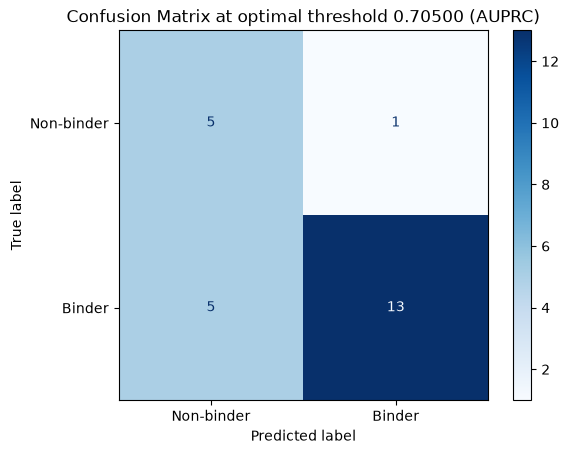

In [17]:
import numpy as np
from sklearn.metrics import precision_score, precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict probabilities
val_df["p_binder"] = clf.predict_proba(X_val)[:, 1]
ranked = val_df.sort_values("p_binder", ascending=False)[["sample", "binder", "p_binder"]]
print(ranked)  # .head(20)

# Precision at top 10% (precision@10%)
top_10pct_count = max(1, int(len(ranked) * 0.1))
top_10pct = ranked.head(top_10pct_count)
precision_at_10pct = (top_10pct["binder"] == 1).sum() / top_10pct_count
print(f"Precision at 10% (precision@10): {precision_at_10pct:.3f} ({(top_10pct['binder'] == 1).sum()}/{top_10pct_count})")

# Overall precision at default threshold 0.5
threshold_default = 0.5
pred_binary_default = (val_df["p_binder"] >= threshold_default).astype(int)
overall_precision_default = precision_score(val_df["binder"], pred_binary_default)
print(f"Overall Precision at threshold 0.5: {overall_precision_default:.3f}")

# Find optimal threshold by maximizing area under the precision-recall curve (AUPRC)
precision, recall, thresholds = precision_recall_curve(val_df["binder"], val_df["p_binder"])
# thresholds is length N-1, precision/recall are N, so thresholds[i] is for (precision[i+1], recall[i+1])

# Calculate area under PR curve for each threshold:
prc_areas = []
for i in range(len(thresholds)):
    # Area from threshold i to next, using trapezoidal rule for segment
    # Use points (recall[i], precision[i]), (recall[i+1], precision[i+1])
    prc_areas.append(auc([recall[i], recall[i+1]], [precision[i+1], precision[i]]))  # precision[i+1] aligns with thresholds[i]
prc_areas = np.array(prc_areas)

if len(prc_areas) > 0:
    optimal_idx = np.argmax(prc_areas)
    optimal_threshold = thresholds[optimal_idx]
    # Use the precision at threshold corresponding to (i+1)
    optimal_prec = precision[optimal_idx + 1]
    optimal_rec = recall[optimal_idx + 1]
    print(f"Optimal threshold (max AUPRC segment): {optimal_threshold:.3f} with Precision={optimal_prec:.3f}, Recall={optimal_rec:.3f}")
else:
    optimal_threshold = 0.5  # fallback
    print(f"No valid precision-recall segments: using default threshold {optimal_threshold}")

optimal_threshold = 0.705
# Confusion matrix at optimal threshold by AUPRC
pred_binary_optimal = (val_df["p_binder"] >= optimal_threshold).astype(int)
cm = confusion_matrix(val_df["binder"], pred_binary_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-binder", "Binder"])
fig, ax = plt.subplots()
disp.plot(ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix at optimal threshold {optimal_threshold:.5f} (AUPRC)")
plt.show()

In [18]:
# Print feature importances (coefficients) from the trained logistic regression (inside pipeline)
from sklearn.pipeline import Pipeline

# If clf is a pipeline, retrieve the final estimator
if isinstance(clf, Pipeline):
    # Find LogisticRegression step: scikit-learn Pipeline's steps attribute is a list of (name, estimator) tuples.
    # Usually, it's the last step.
    lr = None
    for name, step in clf.steps:
        if isinstance(step, LogisticRegression):
            lr = step
            break
    if lr is None:
        raise RuntimeError("No LogisticRegression step found in pipeline!")
else:
    lr = clf

# Get feature names after preprocessing (if possible)
try:
    # Try to get feature names from the preprocessing pipeline
    from sklearn.compose import ColumnTransformer
    preprocessor = clf.named_steps.get('preprocessor', None) if isinstance(clf, Pipeline) else None
    if preprocessor and hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = preprocessor.get_feature_names_out()
    else:
        feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"f_{i}" for i in range(X_train.shape[1])]
except Exception:
    feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"f_{i}" for i in range(X_train.shape[1])]

coefs = lr.coef_.ravel()
feature_importance = sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True)
print("Feature importances (by absolute coefficient value):")
for name, coef in feature_importance:
    print(f"{name:30s} {coef: .4f}")

Feature importances (by absolute coefficient value):
cf_ipae                        -0.0488
af3_plddt                       0.0442
boltz_free_per_chain_pair_iptm  0.0427
af3_ipsae                       0.0420
cf_af3_rmsd                    -0.0404
af3_pdockq2                     0.0372
af3_ptm                         0.0348
boltz_free_ipsae                0.0340
boltz_free_plddt                0.0335
af3_lis                         0.0323
af3_pae                        -0.0313
boltz_template_per_chain_pair_iptm  0.0295
boltz_template_ipsae            0.0294
boltz_free_confidence_score     0.0279
boltz_free_iplddt               0.0266
af3_iptm                        0.0254
boltz_template_plddt            0.0246
boltz_template_lis              0.0230
pred_lddt                      -0.0228
boltz_template_pde             -0.0227
af3_iplddt                      0.0224
cf_iptm                        -0.0218
af3_ipae                       -0.0209
cf_iplddt                      -0.0207
boltz_t

# Designs

In [19]:
# esm
design_df_esm = pd.read_csv(f"{base}/esm_o/design.csv")
X_esm = design_df_esm.reindex(columns=feature_cols)     # feature order
y_esm = design_df_esm["binder"]

print(f"test: {len(X_esm)} rows, {X_esm.shape[1]} features, classes={y_esm.value_counts().to_dict()}")
X_esm.head()

test: 611 rows, 49 features, classes={'?': 611}


,af3_pae,af3_plddt,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq2,af3_lis,af3_iptm,af3_ptm,cf_af3_rmsd,...,boltz_template_ptm,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis
0,3.182553,92.499528,3.276786,90.326811,0.529193,0.7101,0.5863,0.85,0.470,0.250,...,0.964060,0.920852,0.976574,0.971758,0.319294,0.783009,0.767286,0.664791,0.9048,0.6995
1,3.488754,92.267829,3.500000,90.518157,0.609263,0.7720,0.6481,0.85,0.465,0.263,...,0.960036,0.943459,0.969304,0.965000,0.351108,0.783537,0.792899,0.725430,0.8240,0.7240
2,3.011102,92.206530,2.396154,90.044905,0.504032,0.7617,0.6002,0.82,0.465,0.230,...,0.974557,0.923822,0.959218,0.948670,0.298299,0.824787,0.796271,0.693045,0.8463,0.7135
3,2.269226,94.804904,1.862500,93.544875,0.632797,0.8774,0.7103,0.88,0.480,0.210,...,0.978769,0.957550,0.979036,0.976557,0.283379,0.555859,0.807693,0.725704,0.9350,0.7687
4,2.677164,93.656199,1.707500,94.587852,0.641583,0.8504,0.6357,0.82,0.475,0.204,...,0.970854,0.853874,0.949477,0.911259,0.303550,1.230041,0.651304,0.415491,0.6259,0.6074


In [20]:
design_df_esm[[c for c in design_df_esm.columns if "cf_" in c]]

,cf_af3_rmsd,cf_pae,cf_plddt,cf_ipae,cf_iplddt,cf_ipsae,cf_pdockq2,cf_lis,cf_iptm,cf_ptm
0,0.250,2.814740,96.297941,2.666875,94.273685,0.547595,0.8282,0.6305,0.90,0.91
1,0.263,3.001042,96.113750,2.904167,94.328332,0.608785,0.8500,0.6747,0.89,0.91
2,0.230,2.814528,96.020391,2.019348,95.082000,0.567973,0.8398,0.6367,0.85,0.91
3,0.210,2.715576,96.487955,2.068333,94.865713,0.502587,0.8426,0.6428,0.87,0.91
4,0.204,2.783805,96.425227,1.717895,95.945294,0.551546,0.8429,0.6253,0.83,0.91
...,...,...,...,...,...,...,...,...,...,...
606,0.289,3.310825,93.875152,2.643182,89.815910,0.469115,0.6692,0.5477,0.78,0.90
607,0.339,2.963243,95.768382,2.169211,94.395262,0.690450,0.8250,0.6614,0.85,0.91
608,0.203,3.223751,94.440515,3.388269,90.271365,0.545024,0.6302,0.5841,0.84,0.91
609,0.220,3.216199,95.243864,1.759250,95.210526,0.638340,0.7943,0.6551,0.87,0.91


In [21]:
# germinal
design_df_germ = pd.read_csv(f"{base}/germinal_o/design.csv")
X_germ = design_df_germ.reindex(columns=feature_cols)     # feature order
y_germ = design_df_germ["binder"]

print(f"test: {len(X_germ)} rows, {X_germ.shape[1]} features, classes={y_germ.value_counts().to_dict()}")
X_germ.head()

test: 78 rows, 49 features, classes={'?': 78}


,af3_pae,af3_plddt,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq2,af3_lis,af3_iptm,af3_ptm,cf_af3_rmsd,...,boltz_template_ptm,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis
0,3.322382,90.335127,2.098148,86.201647,0.571657,0.6763,0.6213,0.85,0.460,0.215,...,0.970444,0.908755,0.883448,0.815639,0.320832,0.854608,0.759241,0.631073,0.4297,0.6889
1,3.128290,90.846323,3.200000,83.108965,0.220420,0.4583,0.4555,0.69,0.465,3.683,...,0.976071,0.956010,0.920385,0.863982,0.286620,0.532108,0.829751,0.797058,0.5774,0.7693
2,3.935486,87.216988,3.079412,72.497584,0.134186,0.2470,0.3760,0.58,0.455,0.249,...,0.951938,0.845943,0.917523,0.882349,0.388949,1.394980,0.637093,0.407489,0.5348,0.5822
3,3.752704,89.950981,3.476190,90.924828,0.691094,0.7754,0.6466,0.86,0.455,0.279,...,0.946601,0.897160,0.916368,0.880887,0.386413,0.983190,0.740995,0.622386,0.5899,0.6538
4,3.297235,92.097024,2.508696,91.298193,0.643855,0.7592,0.6246,0.83,0.465,0.172,...,0.942231,0.881370,0.950277,0.940627,0.400207,1.059580,0.740361,0.611836,0.7462,0.6427


In [ ]:
# Score the design sets first (self-contained), then take the top candidates per method.
X_esm_input = X_esm.drop(columns=[c for c in ["p_binder", "p_binder_clf"] if c in X_esm.columns])
X_germ_input = X_germ.drop(columns=[c for c in ["p_binder", "p_binder_clf"] if c in X_germ.columns])
X_esm["p_binder"] = rf.predict_proba(X_esm_input)[:, 1]
X_germ["p_binder"] = rf.predict_proba(X_germ_input)[:, 1]

X_esm_with_sample = X_esm.copy()
X_germ_with_sample = X_germ.copy()
X_esm_with_sample['sample'] = design_df_esm.loc[X_esm_with_sample.index, 'sample'].values
X_germ_with_sample['sample'] = design_df_germ.loc[X_germ_with_sample.index, 'sample'].values
X_germ_with_sample['method'] = 'germinal'
X_esm_with_sample['method'] = 'esm'

# NOTE: the 34 / 6 split is a MANUAL selection budget (how many candidates to carry forward per
# method), not a tuned quantity -- document/justify before using downstream.
combined_df = pd.concat([X_esm_with_sample.sort_values("p_binder", ascending=False).head(34),
                         X_germ_with_sample.sort_values("p_binder", ascending=False).head(6)], axis=0, ignore_index=True)

combined_df = combined_df.sort_values("p_binder", ascending=False)[["method", "sample", "p_binder"]]
combined_df['sequence'] = ''

def get_sequence_from_fasta(fasta_path, sample_ids):
    seq_map = {}
    with open(fasta_path, 'r') as file:
        lines = file.readlines()
    for i, line in enumerate(lines):
        if line.startswith('>'):
            sample_name = line[1:].strip()
            if sample_name in sample_ids:
                seq_map[sample_name] = lines[i + 1].strip() if (i + 1) < len(lines) else ""
    return seq_map

esm_fasta = f'{EXTERNAL_DATA_ROOT}/candidates/esm/esm_first_designs.fasta'
germinal_fasta = f'{EXTERNAL_DATA_ROOT}/candidates/germinal/germinal_first_designs.fasta'

esm_samples = set(combined_df.loc[combined_df['method'] == 'esm', 'sample'])
germ_samples = set(combined_df.loc[combined_df['method'] == 'germinal', 'sample'])

esm_seq_map = get_sequence_from_fasta(esm_fasta, esm_samples)
germ_seq_map = get_sequence_from_fasta(germinal_fasta, germ_samples)

for i, row in combined_df.iterrows():
    if row['method'] == 'esm':
        combined_df.at[i, 'sequence'] = esm_seq_map.get(row['sample'], "")
    else:
        combined_df.at[i, 'sequence'] = germ_seq_map.get(row['sample'], "")

combined_df.to_csv("design_RFselected_scores_v2.csv", index=False)
combined_df

In [41]:
def get_sequence_from_fasta(fasta_path, sample_ids):
    seq_map = {}
    with open(fasta_path, 'r') as file:
        lines = file.readlines()
    for i, line in enumerate(lines):
        if line.startswith('>'):
            sample_name = line[1:].strip()
            if sample_name in sample_ids:
                # The next line is the sequence
                seq_map[sample_name] = lines[i + 1].strip() if (i + 1) < len(lines) else ""
    return seq_map

X_esm_input = X_esm.drop(columns=[col for col in ["p_binder", "p_binder_clf"] if col in X_esm.columns])
X_germ_input = X_germ.drop(columns=[col for col in ["p_binder", "p_binder_clf"] if col in X_germ.columns])
X_esm["p_binder"] = rf.predict_proba(X_esm_input)[:, 1]
X_germ["p_binder"] = rf.predict_proba(X_germ_input)[:, 1]
threshold_germ = 0.5
threshold_esm = 0.63
esm_fasta = f'{EXTERNAL_DATA_ROOT}/candidates/esm/esm_first_designs.fasta'
germinal_fasta = f'{EXTERNAL_DATA_ROOT}/candidates/germinal/germinal_first_designs.fasta'

X_esm_with_sample = X_esm.copy()
X_germ_with_sample = X_germ.copy()
X_esm_with_sample['sample'] = design_df_esm.loc[X_esm_with_sample.index, 'sample'].values
X_germ_with_sample['sample'] = design_df_germ.loc[X_germ_with_sample.index, 'sample'].values
X_germ_with_sample['method'] = 'germinal'
X_esm_with_sample['method'] = 'esm'
X_esm_with_sample_pass = X_esm_with_sample[X_esm_with_sample["p_binder"] >= threshold_esm]
X_germ_with_sample_pass = X_germ_with_sample[X_germ_with_sample["p_binder"] >= threshold_germ]
esm_seq_map = get_sequence_from_fasta(esm_fasta, X_esm_with_sample_pass['sample'].unique())
germ_seq_map = get_sequence_from_fasta(germinal_fasta, X_germ_with_sample_pass['sample'].unique())

# for n, seq in esm_seq_map.items():
#     with open(f"/scicore/home/schwede/follon0000/test/data/candidates_filtered/fastas_33mer/{n}.fa", "w") as file:
#         file.write(f">{n}_A\n{seq.split(':')[0]}\n")
#         file.write(f">{n}_B\nLQLQPFPQPQLPYPQPQLPYPQPQLPYPQPQPF\n")
#     with open(f"/scicore/home/schwede/follon0000/test/data/candidates_filtered/fastas_full/{n}.fa", "w") as file:
#         file.write(f">{n}_A\n{seq.split(':')[0]}\n")
#         file.write(f">{n}_B\nVRVPVPQLQPQNPSQQQPQEQVPLVQQQQFPGQQQPFPPQQPYPQPQPFPSQQPYLQLQPFPQPQLPYPQPQLPYPQPQLPYPQPQPFRPQQPYPQSQPQYSQPQQPISQQQQQQQQQQQQKQQQQQQQQILQQILQQQLIPCRDVVLQQHSIAYGSSQVLQQSTYQLVQQLCCQQLWQIPEQSRCQAIHNVVHAIILHQQQQQQQQQQQQPLSQVSFQQPQQQYPSGQGSFQPSQQNPQAQGSVQPQQLPQFEEIRNLALETLPAMCNVYIPPYCTIAPVGIFGTN\n")
# for n, seq in germ_seq_map.items():
#     with open(f"/scicore/home/schwede/follon0000/test/data/candidates_filtered/fastas_33mer/{n}.fa", "w") as file:
#         file.write(f">{n}_A\n{seq.split(':')[0]}\n")
#         file.write(f">{n}_B\nLQLQPFPQPQLPYPQPQLPYPQPQLPYPQPQPF\n")
#     with open(f"/scicore/home/schwede/follon0000/test/data/candidates_filtered/fastas_full/{n}.fa", "w") as file:
#         file.write(f">{n}_A\n{seq.split(':')[0]}\n")
#         file.write(f">{n}_B\nVRVPVPQLQPQNPSQQQPQEQVPLVQQQQFPGQQQPFPPQQPYPQPQPFPSQQPYLQLQPFPQPQLPYPQPQLPYPQPQLPYPQPQPFRPQQPYPQSQPQYSQPQQPISQQQQQQQQQQQQKQQQQQQQQILQQILQQQLIPCRDVVLQQHSIAYGSSQVLQQSTYQLVQQLCCQQLWQIPEQSRCQAIHNVVHAIILHQQQQQQQQQQQQPLSQVSFQQPQQQYPSGQGSFQPSQQNPQAQGSVQPQQLPQFEEIRNLALETLPAMCNVYIPPYCTIAPVGIFGTN\n")
    


In [45]:
all_good_structures = ['nb_cdr3_12_51_0_gliadin_8mer','nb_cdr3_12_280_2_gliadin_8mer','nb_cdr3_16_150_2_gliadin_8mer']

In [52]:
X_esm_with_sample_pass.columns

Index(['af3_pae', 'af3_plddt', 'af3_ipae', 'af3_iplddt', 'af3_ipsae',
       'af3_pdockq2', 'af3_lis', 'af3_iptm', 'af3_ptm', 'cf_af3_rmsd',
       'cf_pae', 'cf_plddt', 'cf_ipae', 'cf_iplddt', 'cf_ipsae', 'cf_pdockq2',
       'cf_lis', 'cf_iptm', 'cf_ptm', 'pred_ilddt', 'pred_lddt',
       'esmfold2_ipae', 'esmfold2_iplddt', 'esmfold2_plddt', 'esmfold2_pae',
       'esmfold2_ptm', 'esmfold2_iptm', 'boltz_free_confidence_score',
       'boltz_free_ptm', 'boltz_free_iptm', 'boltz_free_plddt',
       'boltz_free_iplddt', 'boltz_free_pde', 'boltz_free_ipde',
       'boltz_free_per_chain_pair_iptm', 'boltz_free_ipsae',
       'boltz_free_pdockq2', 'boltz_free_lis',
       'boltz_template_confidence_score', 'boltz_template_ptm',
       'boltz_template_iptm', 'boltz_template_plddt', 'boltz_template_iplddt',
       'boltz_template_pde', 'boltz_template_ipde',
       'boltz_template_per_chain_pair_iptm', 'boltz_template_ipsae',
       'boltz_template_pdockq2', 'boltz_template_lis', 'p_binder',

In [54]:
X_esm_with_sample_pass[X_esm_with_sample_pass["sample"].isin(all_good_structures)]

,af3_pae,af3_plddt,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq2,af3_lis,af3_iptm,af3_ptm,cf_af3_rmsd,...,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis,p_binder,p_binder_clf,sample,method
67,2.357739,94.481690,2.087931,94.946608,0.786757,0.8810,0.7311,0.90,0.475,0.240,...,0.263851,0.310311,0.930481,0.934660,0.9619,0.8572,0.750046,0.657640,nb_cdr3_12_51_0_gliadin_8mer,esm
157,2.494781,93.917803,2.069231,93.707090,0.644554,0.8332,0.6669,0.85,0.475,0.256,...,0.281818,0.464503,0.893635,0.877850,0.9625,0.8022,0.660246,0.611019,nb_cdr3_12_280_2_gliadin_8mer,esm
405,2.193733,95.143552,1.780435,95.302755,0.836647,0.9103,0.7349,0.90,0.480,0.227,...,0.303401,0.828712,0.764275,0.625954,0.9087,0.6715,0.644143,0.576605,nb_cdr3_16_150_2_gliadin_8mer,esm


In [47]:
X_esm_with_sample_pass.sort_values("p_binder", ascending=False).head(12)

,af3_pae,af3_plddt,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq2,af3_lis,af3_iptm,af3_ptm,cf_af3_rmsd,...,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis,p_binder,p_binder_clf,sample,method
285,2.309929,94.509229,2.059615,93.755559,0.786510,0.8859,0.7307,0.89,0.480,0.204,...,0.265396,0.352772,0.897938,0.895260,0.9312,0.8316,0.796149,0.649472,nb_cdr3_16_202_3_gliadin_8mer,esm
67,2.357739,94.481690,2.087931,94.946608,0.786757,0.8810,0.7311,0.90,0.475,0.240,...,0.263851,0.310311,0.930481,0.934660,0.9619,0.8572,0.750046,0.657640,nb_cdr3_12_51_0_gliadin_8mer,esm
467,2.599265,93.810641,2.325926,94.013220,0.769628,0.8710,0.7196,0.90,0.470,0.177,...,0.271423,0.393738,0.860065,0.840744,0.9345,0.8169,0.747667,0.618749,nb_cdr3_16_4_0_gliadin_8mer,esm
569,2.602847,93.118431,2.336538,92.432862,0.782663,0.8557,0.7075,0.87,0.475,0.191,...,0.270045,0.359140,0.891056,0.887432,0.9453,0.8270,0.735834,0.642112,nb_cdr3_16_57_0_gliadin_8mer,esm
205,2.136754,95.170621,1.904348,95.821637,0.836949,0.9206,0.7666,0.92,0.480,0.273,...,0.276254,0.478348,0.830549,0.799031,0.9419,0.7790,0.734959,0.625055,nb_cdr3_16_112_1_gliadin_8mer,esm
473,2.378119,94.676810,1.770000,94.968086,0.828655,0.8873,0.7066,0.86,0.480,0.210,...,0.263561,0.350575,0.931588,0.934544,0.9596,0.8384,0.731153,0.662007,nb_cdr3_12_354_3_gliadin_8mer,esm
519,2.586083,93.986754,2.190385,95.124277,0.820777,0.9029,0.7445,0.89,0.475,0.300,...,0.289341,0.406243,0.898276,0.892900,0.9527,0.8182,0.728448,0.631263,nb_cdr3_20_264_3_gliadin_8mer,esm
580,2.375555,94.254547,1.840000,94.935458,0.804095,0.8951,0.7397,0.89,0.475,0.234,...,0.273310,0.404535,0.898426,0.894513,0.9598,0.8121,0.724728,0.655416,nb_cdr3_12_222_1_gliadin_8mer,esm
173,2.330975,94.638010,2.146296,94.682904,0.813156,0.9086,0.7522,0.91,0.480,0.237,...,0.279506,0.444450,0.865087,0.849217,0.9408,0.7921,0.724532,0.617333,nb_cdr3_16_461_0_gliadin_8mer,esm
313,2.289192,95.276884,2.218750,96.510680,0.841848,0.9282,0.7780,0.93,0.485,0.272,...,0.290189,0.455230,0.899467,0.891468,0.9080,0.7966,0.718042,0.644700,nb_cdr3_20_111_1_gliadin_8mer,esm


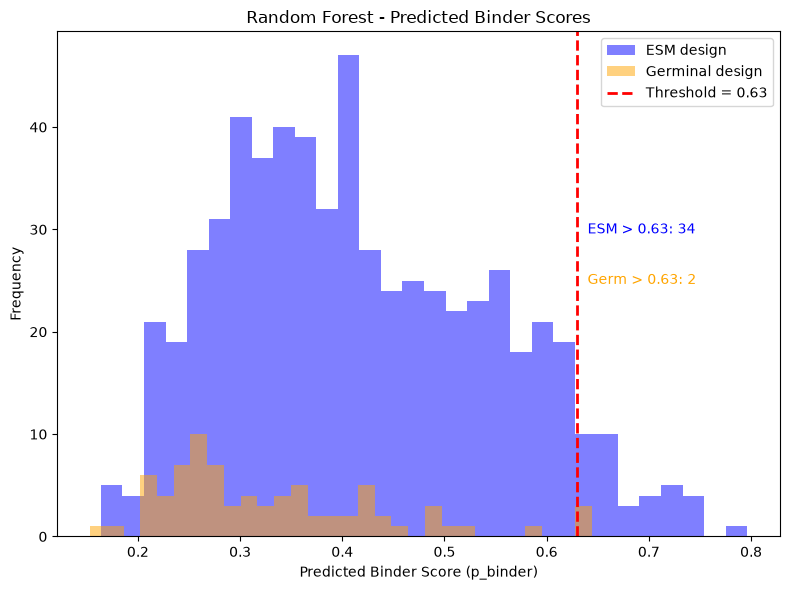

In [24]:
import matplotlib.pyplot as plt

X_esm_input = X_esm.drop(columns=[col for col in ["p_binder", "p_binder_clf"] if col in X_esm.columns])
X_germ_input = X_germ.drop(columns=[col for col in ["p_binder", "p_binder_clf"] if col in X_germ.columns])
X_esm["p_binder"] = rf.predict_proba(X_esm_input)[:, 1]
X_germ["p_binder"] = rf.predict_proba(X_germ_input)[:, 1]

threshold = 0.63

n_esm_above = (X_esm["p_binder"] >= threshold).sum()
n_germ_above = (X_germ["p_binder"] >= threshold).sum()

plt.figure(figsize=(8, 6))
plt.hist(X_esm["p_binder"], bins=30, alpha=0.5, color='blue', label='ESM design')
plt.hist(X_germ["p_binder"], bins=30, alpha=0.5, color='orange', label='Germinal design')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Threshold = {threshold}')

# Add text to show counts passing threshold for each group
ymax = plt.gca().get_ylim()[1]
plt.text(threshold + 0.01, ymax*0.6, f'ESM > {threshold}: {n_esm_above}', color='blue')
plt.text(threshold + 0.01, ymax*0.5, f'Germ > {threshold}: {n_germ_above}', color='orange')

plt.xlabel("Predicted Binder Score (p_binder)")
plt.ylabel("Frequency")
plt.title("Random Forest - Predicted Binder Scores")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
X_esm

,af3_pae,af3_plddt,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq2,af3_lis,af3_iptm,af3_ptm,cf_af3_rmsd,...,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis,p_binder
0,3.182553,92.499528,3.276786,90.326811,0.529193,0.7101,0.5863,0.85,0.470,0.250,...,0.920852,0.976574,0.971758,0.319294,0.783009,0.767286,0.664791,0.9048,0.6995,0.435761
1,3.488754,92.267829,3.500000,90.518157,0.609263,0.7720,0.6481,0.85,0.465,0.263,...,0.943459,0.969304,0.965000,0.351108,0.783537,0.792899,0.725430,0.8240,0.7240,0.523241
2,3.011102,92.206530,2.396154,90.044905,0.504032,0.7617,0.6002,0.82,0.465,0.230,...,0.923822,0.959218,0.948670,0.298299,0.824787,0.796271,0.693045,0.8463,0.7135,0.436457
3,2.269226,94.804904,1.862500,93.544875,0.632797,0.8774,0.7103,0.88,0.480,0.210,...,0.957550,0.979036,0.976557,0.283379,0.555859,0.807693,0.725704,0.9350,0.7687,0.629687
4,2.677164,93.656199,1.707500,94.587852,0.641583,0.8504,0.6357,0.82,0.475,0.204,...,0.853874,0.949477,0.911259,0.303550,1.230041,0.651304,0.415491,0.6259,0.6074,0.438948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,4.037138,89.982010,3.607500,81.461905,0.226378,0.3576,0.4131,0.67,0.460,0.289,...,0.933790,0.952317,0.945606,0.309562,0.787150,0.775386,0.682087,0.8355,0.7296,0.213832
607,3.669588,91.780876,3.640385,86.064073,0.412997,0.5739,0.5354,0.78,0.460,0.339,...,0.871047,0.958739,0.946238,0.343710,1.254443,0.666665,0.453411,0.7753,0.6061,0.292060
608,3.613489,90.886546,3.855357,86.699886,0.436483,0.5619,0.5234,0.79,0.465,0.203,...,0.925426,0.941247,0.910268,0.379497,1.036061,0.789400,0.690601,0.6924,0.6965,0.258424
609,3.474483,92.334911,2.380435,91.577552,0.632199,0.7845,0.6574,0.87,0.465,0.220,...,0.956936,0.939476,0.901295,0.271063,0.492083,0.854318,0.830740,0.7057,0.8015,0.532357


In [ ]:
not_lolos_good_structures = ['nb_cdr3_12_51_0_gliadin_8mer_seed4','nb_cdr3_12_280_2_gliadin_8mer_seed1','nb_cdr3_16_150_2_gliadin_8mer_seed4']

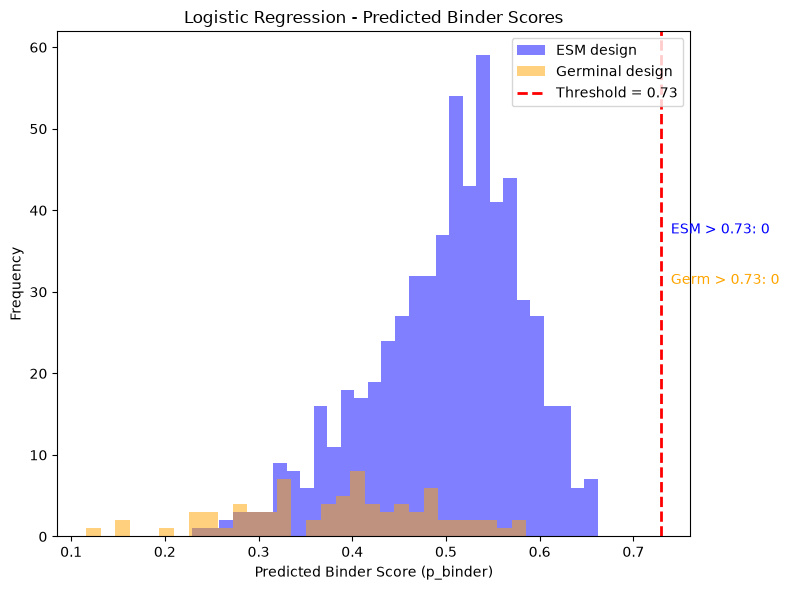

In [38]:
import matplotlib.pyplot as plt

X_esm_clf_input = X_esm.drop(columns=[col for col in ["p_binder", "p_binder_clf"] if col in X_esm.columns])
X_germ_clf_input = X_germ.drop(columns=[col for col in ["p_binder", "p_binder_clf"] if col in X_germ.columns])
X_esm["p_binder_clf"] = clf.predict_proba(X_esm_clf_input)[:, 1]
X_germ["p_binder_clf"] = clf.predict_proba(X_germ_clf_input)[:, 1]

threshold = 0.73

n_esm_above = (X_esm["p_binder_clf"] >= threshold).sum()
n_germ_above = (X_germ["p_binder_clf"] >= threshold).sum()

plt.figure(figsize=(8, 6))
plt.hist(X_esm["p_binder_clf"], bins=30, alpha=0.5, color='blue', label='ESM design')
plt.hist(X_germ["p_binder_clf"], bins=30, alpha=0.5, color='orange', label='Germinal design')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Threshold = {threshold}')

# Add text to show counts passing threshold for each group
ymax = plt.gca().get_ylim()[1]
plt.text(threshold + 0.01, ymax*0.6, f'ESM > {threshold}: {n_esm_above}', color='blue')
plt.text(threshold + 0.01, ymax*0.5, f'Germ > {threshold}: {n_germ_above}', color='orange')

plt.xlabel("Predicted Binder Score (p_binder)")
plt.ylabel("Frequency")
plt.title("Logistic Regression - Predicted Binder Scores")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## With 33mer and full gliadin

In [32]:
import os
import pandas as pnd
# Define the folder path
folder_path = f"{_SCHWEDE}/follon0000/test/data/candidates_filtered/fastas_33mer_esmfold2"

# List all CSV files in the folder
csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".csv")]

# Read and append all CSVs
dfs = []
for csv_file in csv_files:
    try:
        df = pnd.read_csv(csv_file)
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")

# Concatenate all DataFrames into one
results_33mer = pnd.concat(dfs, ignore_index=True)

# Define the folder path
folder_path = f"{_SCHWEDE}/follon0000/test/data/candidates_filtered/fastas_full_esmfold2"

# List all CSV files in the folder
csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".csv")]

# Read and append all CSVs
dfs = []
for csv_file in csv_files:
    try:
        df = pnd.read_csv(csv_file)
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")

# Concatenate all DataFrames into one
results_full = pnd.concat(dfs, ignore_index=True)
results_full

,name,seed,sample,n_chains,total_L,mean_plddt,ptm,iptm,cif,pae_json,interface_scores_json,distogram_npz
0,nb_cdr3_16_4_0_gliadin_8mer,0,0,2,411,59.55,0.381,0.147,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
1,nb_cdr3_16_4_0_gliadin_8mer,1,0,2,411,60.37,0.390,0.189,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
2,nb_cdr3_16_4_0_gliadin_8mer,2,0,2,411,58.99,0.359,0.101,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
3,nb_cdr3_16_4_0_gliadin_8mer,3,0,2,411,59.48,0.384,0.206,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
4,nb_cdr3_16_4_0_gliadin_8mer,4,0,2,411,60.00,0.387,0.155,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
195,nb_s599155_cdr16_gliadin_8mer,0,0,2,407,58.08,0.369,0.140,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
196,nb_s599155_cdr16_gliadin_8mer,1,0,2,407,56.82,0.356,0.117,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
197,nb_s599155_cdr16_gliadin_8mer,2,0,2,407,57.89,0.372,0.141,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
198,nb_s599155_cdr16_gliadin_8mer,3,0,2,407,59.56,0.374,0.233,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN


In [33]:
results_33mer = results_33mer.sort_values("iptm", ascending=False).groupby("name").first().reset_index()
results_full = results_full.sort_values("iptm", ascending=False).groupby("name").first().reset_index()

In [34]:
results_33mer[results_33mer["name"]=='nb_cdr3_16_90_2_gliadin_8mer']

,name,seed,sample,n_chains,total_L,mean_plddt,ptm,iptm,cif,pae_json,interface_scores_json,distogram_npz
27,nb_cdr3_16_90_2_gliadin_8mer,1,0,2,157,78.82,0.784,0.399,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN


In [35]:
# First, merge design_df_esm with design_df_germ on the appropriate key(s)
# You may need to adjust 'on' or 'how' as needed for your schema
design_df_esm['method'] = 'esm'
design_df_germ['method'] = 'germinal'
design_merged = pnd.concat([design_df_esm, design_df_germ], ignore_index=True)

# Prepare iptm DataFrames for merging
iptm_33mer = results_33mer[['name', 'iptm']].rename(columns={'iptm': 'iptm_33mer'})
iptm_full = results_full[['name', 'iptm']].rename(columns={'iptm': 'iptm_full'})

# Start with esmfold2_iptm (from the design_merged data)
sample_esm = design_merged[['method','sample', 'esmfold2_iptm'] + [col for col in design_merged.columns if col not in ['method','sample', 'esmfold2_iptm']]]

# Merge "sample" with "name" from 33mer and full results
merged_df = (
    sample_esm
    .merge(iptm_33mer, left_on='sample', right_on='name', how='left')
    .merge(iptm_full, left_on='sample', right_on='name', how='left', suffixes=('_33mer', '_full'))
    .drop(['name_33mer', 'name_full'], axis=1)
)

# Rearrange columns for clarity, prioritizing the main metrics up front
cols_priority = ['sample', 'esmfold2_iptm', 'iptm_33mer', 'iptm_full']
other_cols = [col for col in merged_df.columns if col not in cols_priority]
merged_df = merged_df[cols_priority + other_cols]

merged_df = merged_df[~merged_df["iptm_33mer"].isna()][['method','sample', 'esmfold2_iptm', 'iptm_33mer', 'iptm_full']]
merged_df

,method,sample,esmfold2_iptm,iptm_33mer,iptm_full
27,esm,nb_cdr3_12_140_2_gliadin_8mer,0.764521,0.255,0.233
30,esm,nb_cdr3_16_90_2_gliadin_8mer,0.867272,0.399,0.832
67,esm,nb_cdr3_12_51_0_gliadin_8mer,0.890541,0.591,0.434
82,esm,nb_cdr3_16_372_2_gliadin_8mer,0.819839,0.237,0.228
87,esm,nb_cdr3_12_97_3_gliadin_8mer,0.849099,0.144,0.267
90,esm,nb_cdr3_16_36_3_gliadin_8mer,0.791904,0.144,0.292
117,esm,nb_cdr3_20_382_2_gliadin_8mer,0.885057,0.196,0.163
123,esm,nb_cdr3_16_166_1_gliadin_8mer,0.874465,0.356,0.203
157,esm,nb_cdr3_12_280_2_gliadin_8mer,0.871337,0.530,0.202
162,esm,nb_cdr3_16_332_0_gliadin_8mer,0.868698,0.402,0.243


In [36]:
design_merged

,source,type,binder,sample,af3_pae,af3_plddt,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq2,...,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis,binder_type,method
0,esm,design,?,nb_cdr3_20_407_0_gliadin_8mer,3.182553,92.499528,3.276786,90.326811,0.529193,0.7101,...,0.976574,0.971758,0.319294,0.783009,0.767286,0.664791,0.9048,0.6995,Design,esm
1,esm,design,?,nb_cdr3_20_2_3_gliadin_8mer,3.488754,92.267829,3.500000,90.518157,0.609263,0.7720,...,0.969304,0.965000,0.351108,0.783537,0.792899,0.725430,0.8240,0.7240,Design,esm
2,esm,design,?,nb_cdr3_12_100_1_gliadin_8mer,3.011102,92.206530,2.396154,90.044905,0.504032,0.7617,...,0.959218,0.948670,0.298299,0.824787,0.796271,0.693045,0.8463,0.7135,Design,esm
3,esm,design,?,nb_cdr3_16_100_0_gliadin_8mer,2.269226,94.804904,1.862500,93.544875,0.632797,0.8774,...,0.979036,0.976557,0.283379,0.555859,0.807693,0.725704,0.9350,0.7687,Design,esm
4,esm,design,?,nb_cdr3_16_146_1_gliadin_8mer,2.677164,93.656199,1.707500,94.587852,0.641583,0.8504,...,0.949477,0.911259,0.303550,1.230041,0.651304,0.415491,0.6259,0.6074,Design,esm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
684,germinal,design,?,nb_s453202_cdr16_gliadin_8mer,4.704401,85.409439,4.393750,67.991139,0.030840,0.0994,...,0.909096,0.830986,0.343821,0.902772,0.732778,0.586085,0.4232,0.6687,Design,germinal
685,germinal,design,?,nb_s308287_cdr16_gliadin_8mer,5.377667,82.796556,5.996296,73.996677,0.113222,0.1584,...,0.921905,0.874784,0.345111,0.859506,0.756643,0.609039,0.6030,0.6823,Design,germinal
686,germinal,design,?,nb_s149989_cdr16_gliadin_8mer,3.099835,91.972083,2.135714,88.316792,0.639090,0.6691,...,0.895532,0.810111,0.271947,0.412868,0.893628,0.886012,0.4405,0.8136,Design,germinal
687,germinal,design,?,nb_s23271_cdr16_gliadin_8mer,3.986401,89.098924,3.557692,82.213111,0.199353,0.3328,...,0.923824,0.893063,0.322227,0.858272,0.802271,0.694529,0.6720,0.7058,Design,germinal


In [ ]:
# Join the RF-selected candidates (combined_df, above) with the design/iptm table (merged_df,
# built in the previous cell). Produces the final selected-scores CSV.
merged_combined = pd.merge(combined_df, merged_df, on=['sample','method'], suffixes=('_combined', '_merged'))
merged_combined.to_csv("design_RFselected_scores_v2.csv", index=False)

In [153]:
lolo_selection = pnd.read_csv(f"{_SCHWEDE}/follon0000/test/design_RFselected_scores.csv")
lolo_selection

,method,sample,p_binder,sequence
0,esm,nb_cdr3_16_202_3_gliadin_8mer,0.796149,QVQLQESGGGLVQAGGSLRLSCAASEPFTEDDQMAWYRQAPGKERE...
1,esm,nb_cdr3_12_51_0_gliadin_8mer,0.750046,QVQLQESGGGLVQAGGSLRLSCAASEPVGEDKMMAWYRQAPGKERE...
2,esm,nb_cdr3_16_4_0_gliadin_8mer,0.747667,QVQLQESGGGLVQAGGSLRLSCAASEPLSEDDQMAWYRQAPGKERE...
3,esm,nb_cdr3_16_57_0_gliadin_8mer,0.735834,QVQLQESGGGLVQAGGSLRLSCAASEPLEEDQQMAWYRQAPGKERE...
4,esm,nb_cdr3_16_112_1_gliadin_8mer,0.734959,QVQLQESGGGLVQAGGSLRLSCAASEPLSDDSQMAWYRQAPGKERE...
5,esm,nb_cdr3_12_354_3_gliadin_8mer,0.731153,QVQLQESGGGLVQAGGSLRLSCAASEPIENLPQTAWYRQAPGKERE...
6,esm,nb_cdr3_20_264_3_gliadin_8mer,0.728448,QVQLQESGGGLVQAGGSLRLSCAASEPLGSDDLLAWYRQAPGKERE...
7,esm,nb_cdr3_12_222_1_gliadin_8mer,0.724728,QVQLQESGGGLVQAGGSLRLSCAASEPIKEHQQVGWYRQAPGKERE...
8,esm,nb_cdr3_16_461_0_gliadin_8mer,0.724532,QVQLQESGGGLVQAGGSLRLSCAASGPLGEDDQLAWYRQAPGKERE...
9,esm,nb_cdr3_20_111_1_gliadin_8mer,0.718042,QVQLQESGGGLVQAGGSLRLSCAASEPLSDNDVEAWYRQAPGKERE...


In [154]:
results_33mer[results_33mer["name"].isin(lolo_selection["sample"])]

,name,seed,sample,n_chains,total_L,mean_plddt,ptm,iptm,cif,pae_json,interface_scores_json,distogram_npz
1,nb_cdr3_12_222_1_gliadin_8mer,2,0,2,153,80.82,0.798,0.540,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
5,nb_cdr3_12_354_3_gliadin_8mer,0,0,2,153,78.71,0.777,0.404,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
7,nb_cdr3_12_51_0_gliadin_8mer,1,0,2,153,81.27,0.797,0.591,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
9,nb_cdr3_16_112_1_gliadin_8mer,0,0,2,157,82.40,0.807,0.504,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
14,nb_cdr3_16_202_3_gliadin_8mer,2,0,2,157,80.98,0.796,0.461,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
17,nb_cdr3_16_332_0_gliadin_8mer,2,0,2,157,79.46,0.783,0.402,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
23,nb_cdr3_16_461_0_gliadin_8mer,3,0,2,157,81.77,0.800,0.467,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
24,nb_cdr3_16_4_0_gliadin_8mer,2,0,2,157,81.77,0.803,0.567,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
25,nb_cdr3_16_57_0_gliadin_8mer,3,0,2,157,80.54,0.794,0.467,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
28,nb_cdr3_20_111_1_gliadin_8mer,0,0,2,161,81.67,0.806,0.626,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN


In [168]:
tmp = results_full[~results_full["name"].isin(lolo_selection["sample"])]
for i, row in tmp.iterrows():
    ! cp {row['cif']} {_SCHWEDE}/follon0000/test/data/candidates_filtered/to_check/full


In [156]:
results_full[results_full["name"].isin(lolo_selection["sample"])]

,name,seed,sample,n_chains,total_L,mean_plddt,ptm,iptm,cif,pae_json,interface_scores_json,distogram_npz
1,nb_cdr3_12_222_1_gliadin_8mer,3,0,2,407,61.96,0.407,0.317,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
5,nb_cdr3_12_354_3_gliadin_8mer,0,0,2,407,61.17,0.391,0.192,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
7,nb_cdr3_12_51_0_gliadin_8mer,4,0,2,407,58.95,0.359,0.434,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
9,nb_cdr3_16_112_1_gliadin_8mer,3,0,2,411,62.39,0.411,0.394,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
14,nb_cdr3_16_202_3_gliadin_8mer,3,0,2,411,62.70,0.393,0.248,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
17,nb_cdr3_16_332_0_gliadin_8mer,0,0,2,411,62.98,0.400,0.243,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
23,nb_cdr3_16_461_0_gliadin_8mer,4,0,2,411,63.55,0.465,0.485,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
24,nb_cdr3_16_4_0_gliadin_8mer,3,0,2,411,59.48,0.384,0.206,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
25,nb_cdr3_16_57_0_gliadin_8mer,0,0,2,411,61.32,0.389,0.174,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN
28,nb_cdr3_20_111_1_gliadin_8mer,4,0,2,415,61.24,0.378,0.568,/scicore/home/schwede/follon0000/test/data/can...,NaN,NaN,NaN


In [157]:
merged_df

,method,sample,esmfold2_iptm,iptm_33mer,iptm_full
27,esm,nb_cdr3_12_140_2_gliadin_8mer,0.764521,0.255,0.233
30,esm,nb_cdr3_16_90_2_gliadin_8mer,0.867272,0.399,0.832
67,esm,nb_cdr3_12_51_0_gliadin_8mer,0.890541,0.591,0.434
82,esm,nb_cdr3_16_372_2_gliadin_8mer,0.819839,0.237,0.228
87,esm,nb_cdr3_12_97_3_gliadin_8mer,0.849099,0.144,0.267
90,esm,nb_cdr3_16_36_3_gliadin_8mer,0.791904,0.144,0.292
117,esm,nb_cdr3_20_382_2_gliadin_8mer,0.885057,0.196,0.163
123,esm,nb_cdr3_16_166_1_gliadin_8mer,0.874465,0.356,0.203
157,esm,nb_cdr3_12_280_2_gliadin_8mer,0.871337,0.530,0.202
162,esm,nb_cdr3_16_332_0_gliadin_8mer,0.868698,0.402,0.243


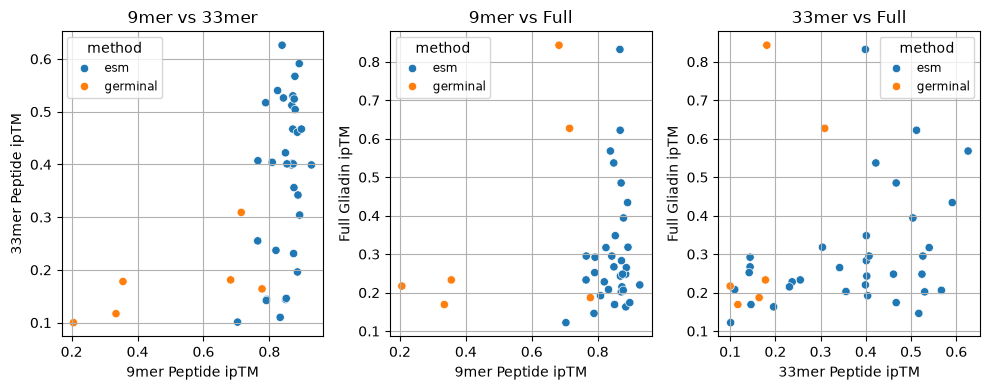

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting environment
plt.figure(figsize=(10, 4))

# 1. esmfold2_iptm vs iptm_33mer
plt.subplot(1, 3, 1)
sns.scatterplot(data=merged_df, x='esmfold2_iptm', y='iptm_33mer', hue='method')
plt.xlabel('9mer Peptide ipTM')
plt.ylabel('33mer Peptide ipTM')
plt.title('9mer vs 33mer')
plt.grid(True)
plt.legend(title='method', loc='best', fontsize='small')

# 2. esmfold2_iptm vs iptm_full
plt.subplot(1, 3, 2)
sns.scatterplot(data=merged_df, x='esmfold2_iptm', y='iptm_full', hue='method')
plt.xlabel('9mer Peptide ipTM')
plt.ylabel('Full Gliadin ipTM')
plt.title('9mer vs Full')
plt.grid(True)
plt.legend(title='method', loc='best', fontsize='small')

# 3. iptm_33mer vs iptm_full
plt.subplot(1, 3, 3)
sns.scatterplot(data=merged_df, x='iptm_33mer', y='iptm_full', hue='method')
plt.xlabel('33mer Peptide ipTM')
plt.ylabel('Full Gliadin ipTM')
plt.title('33mer vs Full')
plt.grid(True)
plt.legend(title='method', loc='best', fontsize='small')

plt.tight_layout()
plt.show()

In [ ]:
good_structures = ['nb_cdr3_12_51_0_gliadin_8mer_seed4']
meh_structures = ['nb_cdr3_20_111_1_gliadin_8mer_seed4','nb_cdr3_20_382_2_gliadin_8mer_seed0','nb_s599155_cdr16_gliadin_8mer_seed3']
bad_binding_site_full = ['nb_cdr3_12_222_1_gliadin_8mer_seed3','nb_cdr3_16_4_0_gliadin_8mer_seed2','nb_cdr3_16_57_0_gliadin_8mer_seed0','nb_cdr3_16_112_1_gliadin_8mer_seed0','nb_cdr3_16_202_3_gliadin_8mer_seed3','nb_cdr3_16_332_0_gliadin_8mer_seed0','nb_cdr3_16_461_0_gliadin_8mer_seed4','nb_cdr3_20_264_3_gliadin_8mer_seed2','nb_s126783_cdr20_gliadin_8mer_seed2','nb_s181248_cdr16_gliadin_8mer_seed3','nb_s303364_cdr20_gliadin_8mer_seed3','nb_s337710_cdr20_gliadin_8mer_seed2','nb_s589675_cdr20_gliadin_8mer_seed4']
not_lolos_good_structures = ['nb_cdr3_12_280_2_gliadin_8mer_seed1','nb_cdr3_16_150_2_gliadin_8mer_seed4']
not_lolos_meh_structures = ['nb_cdr3_12_140_2_gliadin_8mer_seed1','nb_cdr3_16_36_3_gliadin_8mer_seed2','nb_cdr3_20_262_1_gliadin_8mer_seed4']
not_lolos_bad_binding_site_full = ['nb_cdr3_12_23_2_gliadin_8mer_seed0','nb_cdr3_12_97_3_gliadin_8mer_seed3','nb_cdr3_12_268_2_gliadin_8mer_seed1','nb_cdr3_12_374_2_gliadin_8mer_seed2','nb_cdr3_16_22_0_gliadin_8mer_seed1','nb_cdr3_16_26_3_gliadin_8mer_seed0','nb_cdr3_16_43_0_gliadin_8mer_seed0','nb_cdr3_16_62_1_gliadin_8mer_seed1','nb_cdr3_16_90_2_gliadin_8mer_seed1','nb_cdr3_16_130_0_gliadin_8mer_seed3','nb_cdr3_16_131_1_gliadin_8mer_seed2','nb_cdr3_16_166_1_gliadin_8mer_seed2','nb_cdr3_16_372_2_gliadin_8mer_seed3','nb_cdr3_16_402_2_gliadin_8mer_seed1','nb_cdr3_16_420_0_gliadin_8mer_seed0','nb_cdr3_20_189_1_gliadin_8mer_seed4','nb_cdr3_20_399_0_gliadin_8mer_seed1']